In [1]:
!python -m pip install lightgbm

In [2]:
import polars as pl
from utils.general_purpose import * 
from utils.validation import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, accuracy_score, roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
import lightgbm as lgb

In [3]:
# VARIABLES
TRAIN_DATA_PATH = "../data/csv_files/train/"
TEST_DATA_PATH = "../data/csv_files/test/"
FEATURE_DEF_PATH = "../data/feature_definitions.csv"

# With polars
POLARS_TRAIN_DATA_PATH = "../data/train/"
POLARS_TEST_DATA_PATH = "../data/test/"

In [4]:
# Set polars config
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(-1)
# Set pandas config (the utils is made by pandas so we need this too)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [5]:
train_data = pl.read_parquet(POLARS_TRAIN_DATA_PATH+"train_data_simple.parquet")
train_data.head()

case_id,date_decision,MONTH,WEEK_NUM,target,actualdpdtolerance_344P,amtinstpaidbefduel24m_4187115A,annuity_780A,annuitynextmonth_57A,applicationcnt_361L,applications30d_658L,applicationscnt_1086L,applicationscnt_464L,applicationscnt_629L,applicationscnt_867L,avgdbddpdlast24m_3658932P,avgdbddpdlast3m_4187120P,avgdbdtollast24m_4525197P,avgdpdtolclosure24_3658938P,avginstallast24m_3658937A,avglnamtstart24m_4525187A,avgmaxdpdlast9m_3716943P,avgoutstandbalancel6m_4187114A,avgpmtlast12m_4525200A,bankacctype_710L,cardtype_51L,clientscnt12m_3712952L,clientscnt3m_3712950L,clientscnt6m_3712949L,clientscnt_100L,clientscnt_1022L,clientscnt_1071L,clientscnt_1130L,clientscnt_157L,clientscnt_257L,clientscnt_304L,clientscnt_360L,clientscnt_493L,clientscnt_533L,clientscnt_887L,clientscnt_946L,cntincpaycont9m_3716944L,cntpmts24_3658933L,commnoinclast6m_3546845L,credamount_770A,credtype_322L,currdebt_22A,currdebtcredtyperange_828A,datefirstoffer_1144D,datelastunpaid_3546854D,daysoverduetolerancedd_3976961L,deferredmnthsnum_166L,disbursedcredamount_1113A,disbursementtype_67L,downpmt_116A,dtlastpmtallstes_4499206D,eir_270L,firstclxcampaign_1125D,firstdatedue_489D,homephncnt_628L,inittransactionamount_650A,inittransactioncode_186L,interestrate_311L,isbidproduct_1095L,isdebitcard_729L,lastactivateddate_801D,lastapplicationdate_877D,lastapprcommoditycat_1041M,lastapprcommoditytypec_5251766M,lastapprcredamount_781A,lastapprdate_640D,lastcancelreason_561M,lastdelinqdate_224D,lastrejectcommoditycat_161M,lastrejectcommodtypec_5251769M,lastrejectcredamount_222A,lastrejectdate_50D,lastrejectreason_759M,lastrejectreasonclient_4145040M,lastst_736L,maininc_215A,mastercontrelectronic_519L,mastercontrexist_109L,maxannuity_159A,maxdbddpdlast1m_3658939P,maxdbddpdtollast12m_3658940P,maxdbddpdtollast6m_4187119P,maxdebt4_972A,maxdpdfrom6mto36m_3546853P,maxdpdinstldate_3546855D,maxdpdinstlnum_3546846P,maxdpdlast12m_727P,maxdpdlast24m_143P,maxdpdlast3m_392P,maxdpdlast6m_474P,maxdpdlast9m_1059P,maxdpdtolerance_374P,maxinstallast24m_3658928A,maxlnamtstart6m_4525199A,maxoutstandbalancel12m_4187113A,maxpmtlast3m_4525190A,mindbddpdlast24m_3658935P,mindbdtollast24m_4525191P,mobilephncnt_593L,monthsannuity_845L,numactivecreds_622L,numactivecredschannel_414L,numactiverelcontr_750L,numcontrs3months_479L,numincomingpmts_3546848L,numinstlallpaidearly3d_817L,numinstls_657L,numinstlsallpaid_934L,numinstlswithdpd10_728L,numinstlswithdpd5_4187116L,numinstlswithoutdpd_562L,numinstmatpaidtearly2d_4499204L,numinstpaid_4499208L,numinstpaidearly3d_3546850L,numinstpaidearly3dest_4493216L,numinstpaidearly5d_1087L,numinstpaidearly5dest_4493211L,numinstpaidearly5dobd_4499205L,numinstpaidearly_338L,numinstpaidearlyest_4493214L,numinstpaidlastcontr_4325080L,numinstpaidlate1d_3546852L,numinstregularpaid_973L,numinstregularpaidest_4493210L,numinsttopaygr_769L,numinsttopaygrest_4493213L,numinstunpaidmax_3546851L,numinstunpaidmaxest_4493212L,numnotactivated_1143L,numpmtchanneldd_318L,numrejects9m_859L,opencred_647L,paytype1st_925L,paytype_783L,pctinstlsallpaidearl3d_427L,pctinstlsallpaidlat10d_839L,pctinstlsallpaidlate1d_3546856L,pctinstlsallpaidlate4d_3546849L,pctinstlsallpaidlate6d_3546844L,pmtnum_254L,posfpd10lastmonth_333P,posfpd30lastmonth_3976960P,posfstqpd30lastmonth_3976962P,previouscontdistrict_112M,price_1097A,sellerplacecnt_915L,sellerplacescnt_216L,sumoutstandtotal_3546847A,sumoutstandtotalest_4493215A,totaldebt_9A,totalsettled_863A,totinstallast1m_4525188A,twobodfilling_608L,typesuite_864L,assignmentdate_238D,assignmentdate_4527235D,assignmentdate_4955616D,birthdate_574D,contractssum_5085716L,dateofbirth_337D,dateofbirth_342D,days120_123L,days180_256L,days30_165L,days360_512L,days90_310L,description_5085714M,education_1103M,education_88M,firstquarter_103L,for3years_128L,for3years_504L,for3years_584L,formonth_118L,formonth_206L,formonth_535L,forquarter_1017L,forquarter_462L,forquarter_634L,fortoday_1092L,forweek_1077L,forweek_528L,forweek_601L,foryear_618L,foryear_818L,foryear_850L,fou

In [6]:
train_data_feature = get_feature_definitions(data_file_path=POLARS_TRAIN_DATA_PATH+"train_data_simple.parquet",
                                             feature_definitions_csv=FEATURE_DEF_PATH)
train_data_feature

,Variable,Description,Data Type
1,actualdpdtolerance_344P,DPD of client with tolerance.,double
14,amtinstpaidbefduel24m_4187115A,Number of instalments paid before due date in the last 24 months.,double
17,annuity_780A,Monthly annuity amount.,double
19,annuitynextmonth_57A,Next month's amount of annuity.,double
20,applicationcnt_361L,Number of applications associated with the same email address as the client.,double
21,applications30d_658L,Number of applications made by the client in the last 30 days.,double
22,applicationscnt_1086L,Number of applications associated with the same phone number.,double
23,applicationscnt_464L,Number of applications made in the last 30 days by other clients with the same employer as the applicant.,double
24,applicationscnt_629L,Number of applications with the same employer in the last 7 days.,double
25,applicationscnt_867L,Number of applications associated with the same mobile phone.,double


In [7]:
import polars as pl
from polars.datatypes import Float64, Float32, Int64, Int32, UInt32, UInt64, Utf8

# define numeric types manually
numeric_types = {Float64, Float32, Int64, Int32, UInt32, UInt64}

# get numeric columns
numeric_cols = [col for col, dtype in zip(train_data.columns, train_data.schema.values())
                if dtype in numeric_types]

# get string columns
string_cols = [col for col, dtype in zip(train_data.columns, train_data.schema.values())
               if dtype == Utf8]


In [8]:
# Fill numeric columns with median
for col in numeric_cols:
    median_val = train_data.select(pl.col(col).median()).item()
    train_data = train_data.with_columns(pl.col(col).fill_null(median_val))

# Fill string columns with "missing"
for col in string_cols:
    train_data = train_data.with_columns(pl.col(col).fill_null("missing"))


In [9]:
df_pandas = train_data.to_pandas()
df_pandas.shape

(1526659, 211)

In [10]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Assume df_pandas is already available and contains the "target" column
# Drop identifier columns if present
X = df_pandas.drop(columns=["target", "case_id"], errors='ignore')
y = df_pandas["target"]

# Convert categorical columns to category dtype
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train LightGBM model
model = lgb.LGBMClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, y_pred_proba)

# Feature importance
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)


auc_score


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 38395, number of negative: 1182932
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.088818 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 60243
[LightGBM] [Info] Number of data points in the train set: 1221327, number of used features: 198
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.031437 -> initscore=-3.427824
[LightGBM] [Info] Start training from score -3.427824


0.7863544228988322

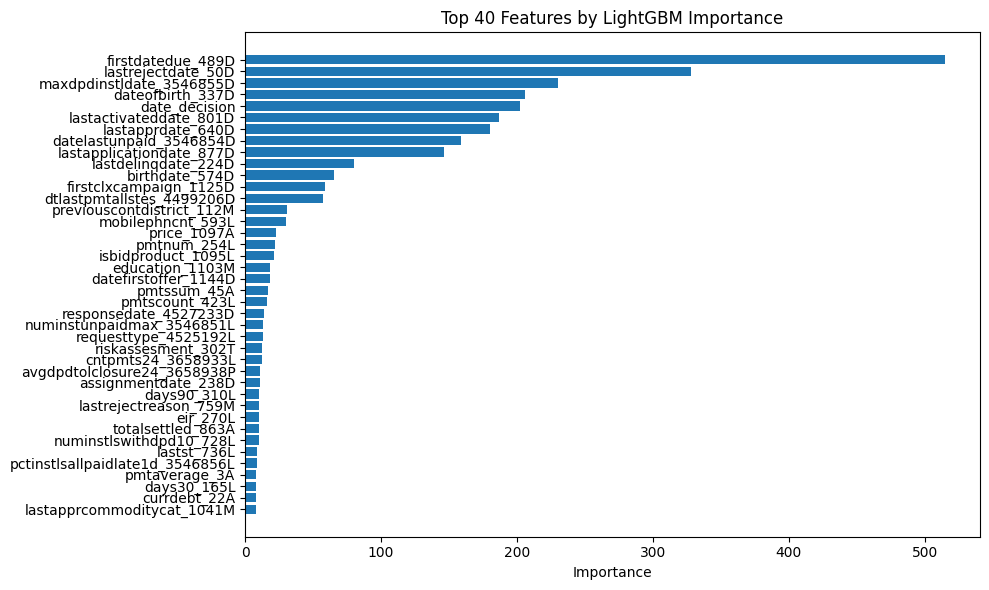

In [11]:
import matplotlib.pyplot as plt

# Plot top 20 features by importance
top_n = 40
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Features by LightGBM Importance")
plt.tight_layout()
plt.show()


In [12]:
feature_importance_df.head(40)

,feature,importance
56,firstdatedue_489D,515
74,lastrejectdate_50D,328
87,maxdpdinstldate_3546855D,230
162,dateofbirth_337D,206
0,date_decision,202
63,lastactivateddate_801D,187
68,lastapprdate_640D,180
47,datelastunpaid_3546854D,159
64,lastapplicationdate_877D,146
70,lastdelinqdate_224D,80


In [13]:
feature_definition_df = pd.read_csv(FEATURE_DEF_PATH)
feature_importance_df.head(40).merge(
    feature_definition_df,
    left_on="feature",
    right_on="Variable",
    how="left"
)


,feature,importance,Variable,Description
0,firstdatedue_489D,515,firstdatedue_489D,Date of the first due date.
1,lastrejectdate_50D,328,lastrejectdate_50D,Date of most recent rejected application by the applicant.
2,maxdpdinstldate_3546855D,230,maxdpdinstldate_3546855D,Date of instalment on which client was most days past due.
3,dateofbirth_337D,206,dateofbirth_337D,Client's date of birth.
4,date_decision,202,NaN,NaN
5,lastactivateddate_801D,187,lastactivateddate_801D,Contract activation date for previous applications.
6,lastapprdate_640D,180,lastapprdate_640D,Date of approval on client's most recent previous application.
7,datelastunpaid_3546854D,159,datelastunpaid_3546854D,Date of the last unpaid instalment.
8,lastapplicationdate_877D,146,lastapplicationdate_877D,Date of previous customer's application.
9,lastdelinqdate_224D,80,lastdelinqdate_224D,Date of the last delinquency occurrence.


In [14]:
list_features = feature_importance_df.head(40)['feature'].tolist()
# Drop identifier columns if present
X = df_pandas[list_features]
y = df_pandas["target"]

# Convert categorical columns to category dtype
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train LightGBM model
model = lgb.LGBMClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_val)[:, 1]
auc_score = roc_auc_score(y_val, y_pred_proba)

# Feature importance
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)


auc_score


/tmp/ipykernel_9539/187275108.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/tmp/ipykernel_9539/187275108.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
/tmp/ipykernel_9539/187275108.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 38395, number of negative: 1182932
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028900 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39703
[LightGBM] [Info] Number of data points in the train set: 1221327, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.031437 -> initscore=-3.427824
[LightGBM] [Info] Start training from score -3.427824


0.7767836299456332

In [20]:
train_data_simple_40F = pd.concat([X,y], axis=1)
train_data_simple_40F.shape

(1526659, 41)

In [ ]:
train_data_simple_40F.to_parquet(POLARS_TRAIN_DATA_PATH+"train_data_simple_40F.parquet", index=False)